# 13. Полная причинная декомпозиция успешности атаки

## Что было известно до этого эксперимента

Мы всегда фиксируем **конкретного clean target person до атаки**: это самый уверенный person detection
на чистом изображении. После патча target считается видимым, только если существует post-NMS person
с `confidence ≥ 0.25` и `IoU ≥ 0.5` с этой чистой target-box. Поэтому исчезновение одного winner,
переключение на другого человека и legacy-label не являются успехом атаки.

К началу этого этапа было установлено:

1. Target-aware ASR равен 34.6% на 5 985 пригодных изображениях; в 2 003 из 2 069 successful cases
   после исчезновения target остаётся видим другой человек.
2. У target имеется clean reserve примерно из 9–10 pre-NMS candidates. Исходная tracked cell остаётся
   winner лишь в 15.7% видимых случаев, а другой уже существовавший candidate спасает target в 71.3%.
   Поэтому `clean-set max` предсказывает hiding лучше tracked score: ROC AUC 0.932 против 0.868.
3. Score-only transplant показывает резкий эффект полного исчерпания reserve: top-8 почти никогда
   недостаточно, top-10 воспроизводит большую часть hiding. Это причинно подтверждает коллективное
   подавление candidates, но само условие следует из max aggregation и не является механизмом.
4. Обычный activation-energy rank-1 отвергнут: он отлично делает repair, но не transplant и почти не
   превосходит random energy controls. Полный delta в `5×5` candidate windows почти достаточен,
   следовательно mediator target-local, но многомерный.
5. Path-integrated Jacobian person logits выделил score-functional row space. Он содержит менее 1%
   локальной activation energy, почти достигает score-only oracle и сильно превосходит energy-matched
   controls. Более 99% feature delta не видны fixed candidate scores в первом порядке.
6. Однако score-subspace объяснял только confidence-маршрут. В `no-IoU` class и box branch часто
   действуют совместно; оставались geometry, NMS, новые/соседние candidates и нелинейная sufficiency.

## Новый вопрос

Можно ли для каждого успешного hiding получить **замкнутое причинное объяснение**, которое:

- разделяет score, geometry и NMS;
- локализует достаточный Detect-input region;
- одновременно учитывает person logits и decoded box IoU;
- отличает необходимый функциональный signal от большого, но самостоятельно бессильного residual?

## Дизайн

Эксперимент имеет два вложенных уровня.

**Exact output closure.** Для всех clean candidates фиксированного target заменяются exact clean→patch
outputs class branch, box branch или обеих ветвей. Получаются взаимоисключающие режимы:
`score_only`, `geometry_only`, `cooperative`, `redundant`; `NMS-only` отмечается отдельно.

**Internal activation closure.** Реальный Detect-input delta переносится в окрестностях радиуса
`0, 1, 2, 4, 8, 16` candidate cells. `radius=2` — объединение `5×5` receptive windows,
`radius=4` — `9×9` causal cone. Параллельно строятся path-integrated Jacobians двух векторов:
person logits и IoU decoded boxes с clean target. SVD объединённого Jacobian задаёт
`joint score+geometry row space`; остаток delta ортогонален ему в первом порядке.

Каждый компонент проверяется в обе стороны:

- **repair:** удалить clean→patch component из patched activation;
- **transplant:** добавить тот же component к clean activation.

Полный перенос всех feature maps служит endpoint sanity check. Ноутбук ничего тяжёлого не считает:
он читает компактные CSV/JSON. Расширенный MPS-run выполнен на всех 400 сбалансированных примерах;
joint-functional intervention больше не ограничен исходным subset из 100 примеров.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "CandidateRoutingAndAttackPath":
    REPO_ROOT = REPO_ROOT.parent
OUTPUT_ROOT = REPO_ROOT / "CandidateRoutingAndAttackPath" / "followup_outputs"

runs = []
for path in OUTPUT_ROOT.glob("full_success_*"):
    summary_path = path / "summary.json"
    if summary_path.exists():
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        if summary.get("status") == "complete":
            runs.append((summary.get("closure_examples", 0), summary.get("functional_examples", 0), path, summary))
if not runs:
    raise FileNotFoundError("Нет completed full_success run")
_, _, RUN_DIR, summary = max(runs, key=lambda item: (item[0], item[1], item[2].stat().st_mtime))

exact = pd.read_csv(RUN_DIR / "exact_output_rows.csv")
exact_summary = pd.read_csv(RUN_DIR / "exact_output_summary.csv")
mechanisms = pd.read_csv(RUN_DIR / "mechanism_rows.csv")
mechanism_summary = pd.read_csv(RUN_DIR / "mechanism_summary.csv")
spatial = pd.read_csv(RUN_DIR / "spatial_cone_rows.csv")
spatial_summary = pd.read_csv(RUN_DIR / "spatial_cone_summary.csv")
functional = pd.read_csv(RUN_DIR / "joint_functional_rows.csv")
functional_summary = pd.read_csv(RUN_DIR / "joint_functional_summary.csv")
metadata = pd.read_csv(RUN_DIR / "joint_functional_metadata.csv")
activation_summary = pd.read_csv(RUN_DIR / "activation_mechanism_summary.csv")

sns.set_theme(style="whitegrid", context="notebook")
GROUP_LABELS = {
    "visible_target_winner": "visible / tracked wins",
    "visible_non_target_winner": "visible / reserve wins",
    "hidden_low_conf_match": "hidden / low confidence",
    "hidden_no_iou_match": "hidden / no IoU",
}
print(f"Run: {RUN_DIR}")
print(f"Elapsed: {summary['elapsed_seconds']:.1f} s")
print(f"Closure examples: {summary['closure_examples']}; functional examples: {summary['functional_examples']}")
print(f"Trace-consistent endpoint-hidden: {summary['endpoint_hidden_examples']}")


Run: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/followup_outputs/full_success_608d1fab828fcafd
Elapsed: 868.7 s
Closure examples: 400; functional examples: 400
Trace-consistent endpoint-hidden: 193


Выбран самый большой completed run: 400 сбалансированных примеров. Из 200 примеров двух исходно
hidden-групп 193 снова воспроизвели hiding в текущем trace-consistent inference; семь нестабильных
`hidden_no_iou` не входят в causal denominator. Это не подмена label: таблицы сохраняют их как
`endpoint_not_hidden`, а все rates sufficiency считаются только относительно реально hidden endpoint.


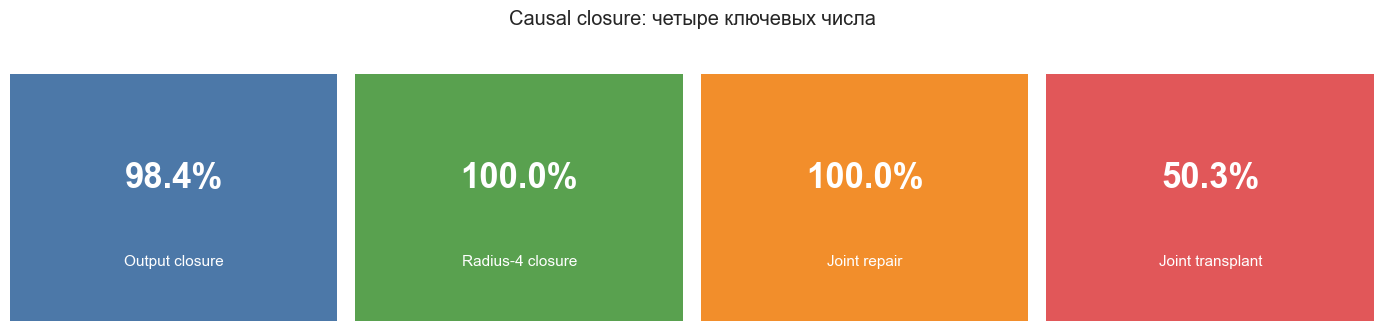

In [2]:
cards = [
    ("Output closure", summary["candidate_output_closure_rate"], "#4C78A8"),
    ("Radius-4 closure", summary["radius4_transplant_closure_rate"], "#59A14F"),
    ("Joint repair", summary["joint_rowspace_repair_rate"], "#F28E2B"),
    ("Joint transplant", summary["joint_rowspace_transplant_rate"], "#E15759"),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (title, value, color) in zip(axes, cards):
    ax.set_facecolor(color)
    ax.text(0.5, 0.58, f"{100*value:.1f}%", ha="center", va="center",
            fontsize=25, weight="bold", color="white")
    ax.text(0.5, 0.24, title, ha="center", va="center", fontsize=11, color="white")
    ax.set(xticks=[], yticks=[], xlim=(0, 1), ylim=(0, 1))
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Causal closure: четыре ключевых числа", y=1.03)
plt.tight_layout()
plt.show()


Главный sanity check пройден: полный Detect-input transplant воспроизводит 193/193 attacks.
Exact replacement outputs только candidate closure закрывает 190/193 (98.4%), а `radius=4`
закрывает уже 193/193. Joint-functional component необходим: его удаление ремонтирует 193/193
воспроизводимых успешных атак. Но один joint component достаточен только в 97/193 (50.3%);
следовательно полная атака не сводится к линейной проекции.


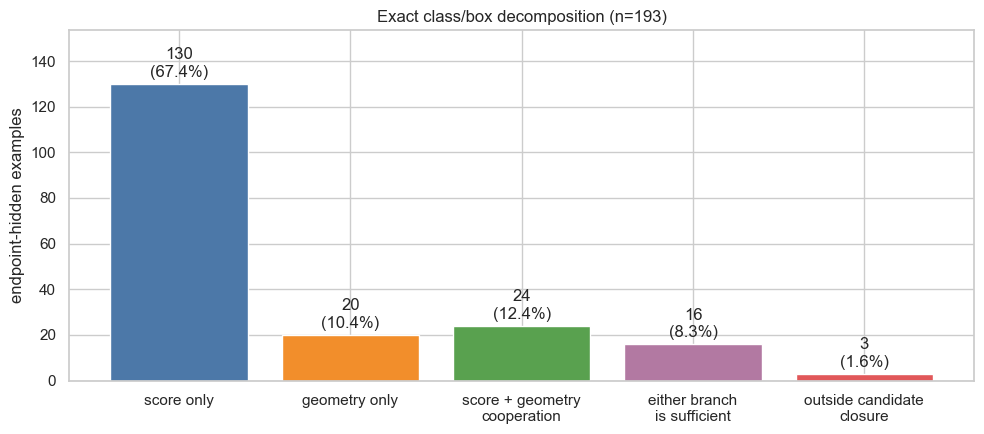

NMS-marked inside candidate closure: 8; global closure failures: 3


In [3]:
hidden_modes = mechanisms[mechanisms.mechanism_mode.ne("endpoint_not_hidden")].copy()
collapsed = hidden_modes.mechanism_mode.str.replace(r"\+nms$", "", regex=True)
order = [
    "score_only", "geometry_only", "cooperative_score_and_geometry",
    "redundant_score_or_geometry", "candidate_closure_failure",
]
counts = collapsed.value_counts().reindex(order, fill_value=0)
labels = ["score only", "geometry only", "score + geometry\ncooperation",
          "either branch\nis sufficient", "outside candidate\nclosure"]
colors = ["#4C78A8", "#F28E2B", "#59A14F", "#B279A2", "#E15759"]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels, counts.values, color=colors)
ax.bar_label(bars, labels=[f"{v}\n({100*v/len(hidden_modes):.1f}%)" for v in counts.values], padding=3)
ax.set_ylabel("endpoint-hidden examples")
ax.set_title(f"Exact class/box decomposition (n={len(hidden_modes)})")
ax.set_ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()

nms_count = int(hidden_modes.mechanism_mode.str.endswith("+nms").sum())
closure_fail = int((hidden_modes.mechanism_mode == "candidate_closure_failure").sum())
print(f"NMS-marked inside candidate closure: {nms_count}; global closure failures: {closure_fail}")


Из 193 воспроизводимых атак 130 (67.4%) — чистый score-route: patched class outputs уже скрывают
target, patched geometry сама по себе — нет. Geometry-only даёт 20 случаев (10.4%).
В 24 случаях (12.4%) ни одна ветвь отдельно не достаточна, но их совместная замена скрывает target:
это настоящая причинная кооперация, а не корреляция. Ещё 16 (8.3%) избыточны — каждая ветвь отдельно
уже достаточна. Три случая (1.6%) требуют outputs вне endpoint candidate closure; все три связаны
с NMS/пограничным IoU и закрываются пространственным experiment. Всего NMS участвует как финальный
порог примерно в 11/193 случаях, но не является главным механизмом.


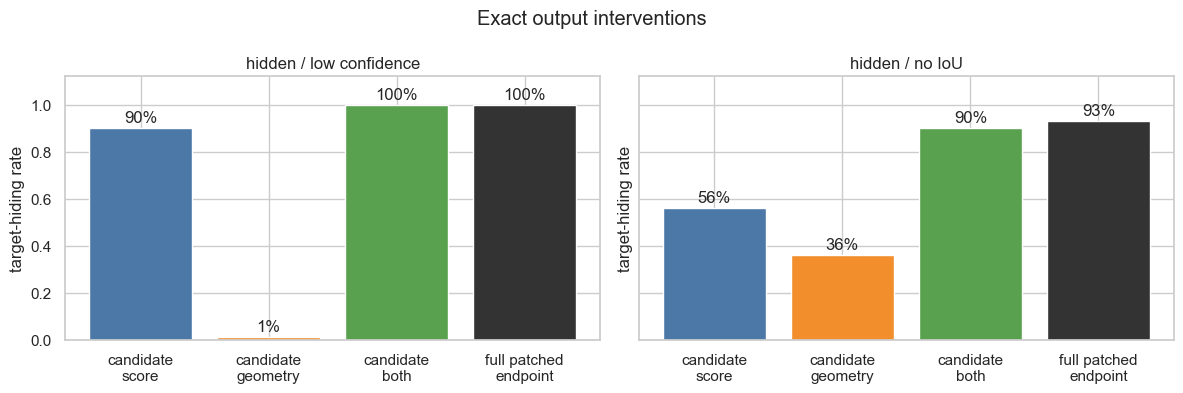

In [4]:
hidden_groups = ["hidden_low_conf_match", "hidden_no_iou_match"]
conditions = ["candidate_score", "candidate_geometry", "candidate_both", "global_both"]
labels = ["candidate\nscore", "candidate\ngeometry", "candidate\nboth", "full patched\nendpoint"]
plot = exact_summary[
    exact_summary.analysis_group.isin(hidden_groups)
    & exact_summary.condition.isin(conditions)
].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, group in zip(axes, hidden_groups):
    values = plot[plot.analysis_group.eq(group)].set_index("condition").reindex(conditions)
    bars = ax.bar(labels, values.target_hidden_rate, color=["#4C78A8", "#F28E2B", "#59A14F", "#333333"])
    ax.bar_label(bars, labels=[f"{100*v:.0f}%" for v in values.target_hidden_rate], padding=2)
    ax.set_title(GROUP_LABELS[group])
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("target-hiding rate")
plt.suptitle("Exact output interventions")
plt.tight_layout()
plt.show()


Low-confidence почти целиком score-mediated: candidate-score replacement скрывает 90%, geometry —
1%, обе ветви — 100%. Для no-IoU картина неоднородна: score даёт 56%, geometry 36%, обе — 90%,
а полный patched endpoint — 93%. Разница между `candidate_both` и endpoint — те самые три
NMS/neighbor cases. Поэтому `no-IoU` — не отдельный «геометрический тип атаки»: в нём смешаны
score-only, geometry-only, redundant и cooperative механизмы.


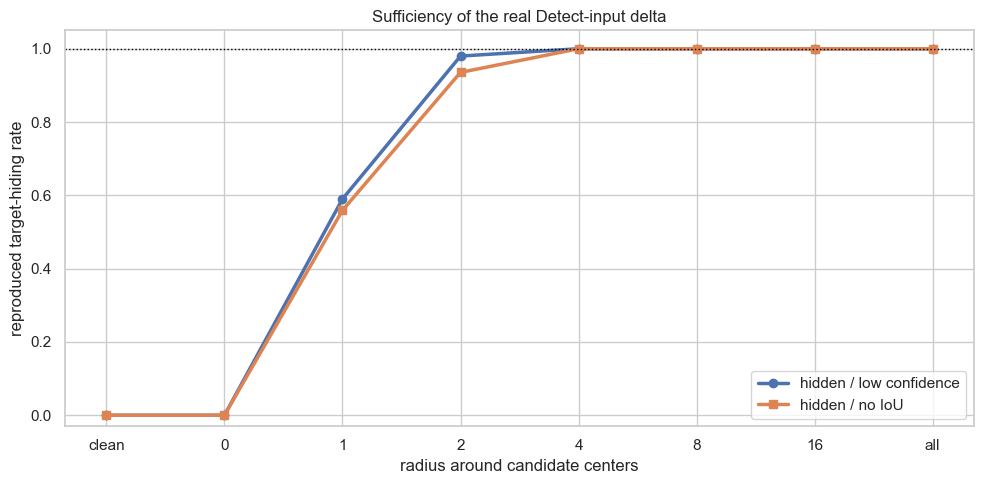

In [5]:
radius_order = ["none", "radius_0", "radius_1", "radius_2", "radius_4", "radius_8", "radius_16", "full_maps"]
xlabels = ["clean", "0", "1", "2", "4", "8", "16", "all"]
plot = spatial_summary[
    spatial_summary.analysis_group.isin(hidden_groups)
    & spatial_summary.direction.eq("transplant_clean")
    & spatial_summary.condition.isin(radius_order)
].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for group, marker in zip(hidden_groups, ["o", "s"]):
    values = plot[plot.analysis_group.eq(group)].set_index("condition").reindex(radius_order)
    ax.plot(xlabels, values.reproduced_hiding_rate, marker=marker, linewidth=2.5,
            label=GROUP_LABELS[group])
ax.axhline(1.0, color="black", linewidth=1, linestyle=":")
ax.set(xlabel="radius around candidate centers", ylabel="reproduced target-hiding rate",
       ylim=(-0.03, 1.05), title="Sufficiency of the real Detect-input delta")
ax.legend()
plt.tight_layout()
plt.show()


Это полное пространственное причинное замыкание. Одна central cell (`radius=0`) не достаточна вообще.
`radius=1` воспроизводит 59.0% low-confidence и 55.9% no-IoU; стандартные `5×5` windows
(`radius=2`) — 98.0% и 93.5%. `9×9` cone (`radius=4`) воспроизводит **100% обеих групп**,
после чего кривая больше не меняется. На двух genuinely visible control groups ни один радиус
не создаёт hiding. Значит, вся успешность локализована не во всём feature map, а в небольшой
окрестности маршрутов target candidates.


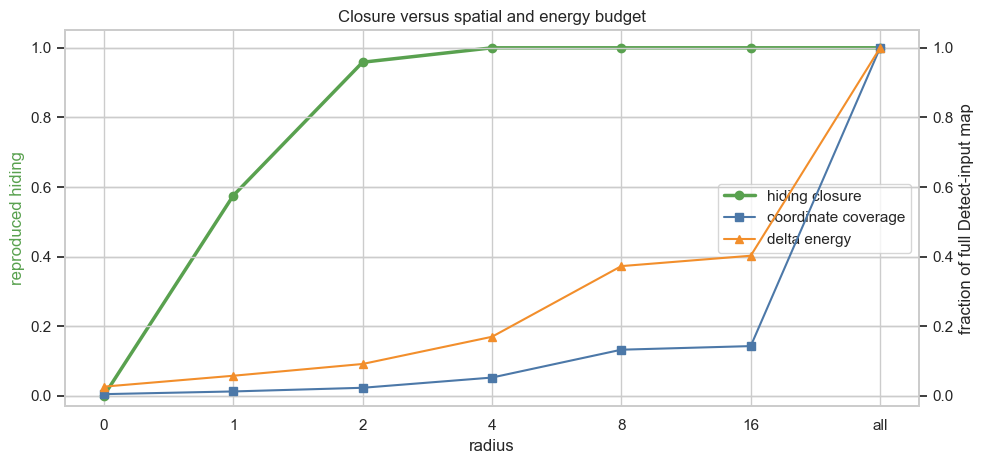

In [6]:
plot = spatial_summary[
    spatial_summary.analysis_group.eq("all")
    & spatial_summary.direction.eq("transplant_clean")
    & spatial_summary.condition.isin(radius_order[1:])
].set_index("condition").reindex(radius_order[1:])
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax1.plot(xlabels[1:], plot.reproduced_hiding_rate, color="#59A14F", marker="o",
         linewidth=2.5, label="hiding closure")
ax1.set_ylabel("reproduced hiding", color="#59A14F")
ax1.set_ylim(-0.03, 1.05)
ax2 = ax1.twinx()
ax2.plot(xlabels[1:], plot.mean_spatial_coverage_fraction, color="#4C78A8", marker="s",
         label="coordinate coverage")
ax2.plot(xlabels[1:], plot.mean_component_energy_fraction, color="#F28E2B", marker="^",
         label="delta energy")
ax2.set_ylabel("fraction of full Detect-input map")
ax2.set_ylim(-0.03, 1.05)
lines = ax1.lines + ax2.lines
ax1.legend(lines, [line.get_label() for line in lines], loc="center right")
ax1.set_xlabel("radius")
ax1.set_title("Closure versus spatial and energy budget")
plt.tight_layout()
plt.show()


`radius=4` использует в среднем только 5.2% координат Detect input и 17.0% полной squared delta energy,
но уже даёт 100% causal closure. `radius=2` использует 2.3% координат и 9.1% energy, теряя лишь
8 из 193 атак. Поэтому объяснение не в глобальном «расползании» патча: решающий mediator
target-local. Дополнительное кольцо `radius 2→4` нужно главным образом для endpoint-consistency
соседних head outputs и NMS, а не для распространения по всей модели.


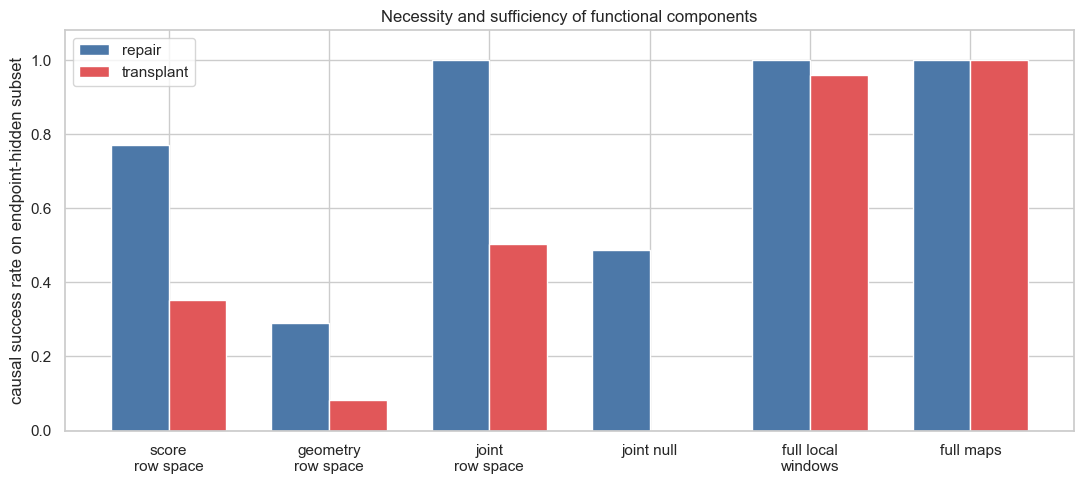

In [7]:
conditions = [
    "score_rowspace", "geometry_rowspace", "joint_rowspace",
    "joint_null", "full_candidate_windows", "full_maps",
]
labels = ["score\nrow space", "geometry\nrow space", "joint\nrow space",
          "joint null", "full local\nwindows", "full maps"]
plot = functional_summary[
    functional_summary.analysis_group.eq("all")
    & functional_summary.condition.isin(conditions)
].copy()
repair = plot[plot.direction.eq("repair_patched")].set_index("condition").reindex(conditions)
transplant = plot[plot.direction.eq("transplant_clean")].set_index("condition").reindex(conditions)
x = np.arange(len(conditions))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.18, repair.recovery_rate, width=0.36, label="repair", color="#4C78A8")
ax.bar(x + 0.18, transplant.reproduced_hiding_rate, width=0.36, label="transplant", color="#E15759")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel("causal success rate on endpoint-hidden subset")
ax.set_title("Necessity and sufficiency of functional components")
ax.legend()
plt.tight_layout()
plt.show()


Score row space один воспроизводит 35.2% attacks, geometry — 8.3%, joint — 50.3%; объединение
действительно сильнее каждой ветви. Главное: удаление joint row space восстанавливает **100%**
targets, то есть он необходим во всех 193 endpoint-hidden examples расширенного run.

Но joint не достаточен примерно в половине случаев. `joint_null` сам не воспроизводит ни одной атаки,
хотя содержит почти всю локальную energy. Вместе с joint (`full local windows`) они дают уже 95.9%.
Это прямое доказательство нелинейной кооперации: residual не является самостоятельным attack signal,
но меняет режим/gain head так, что функциональное направление пересекает confidence/IoU thresholds.
Внешний контекст доводит 95.9% до 100%.


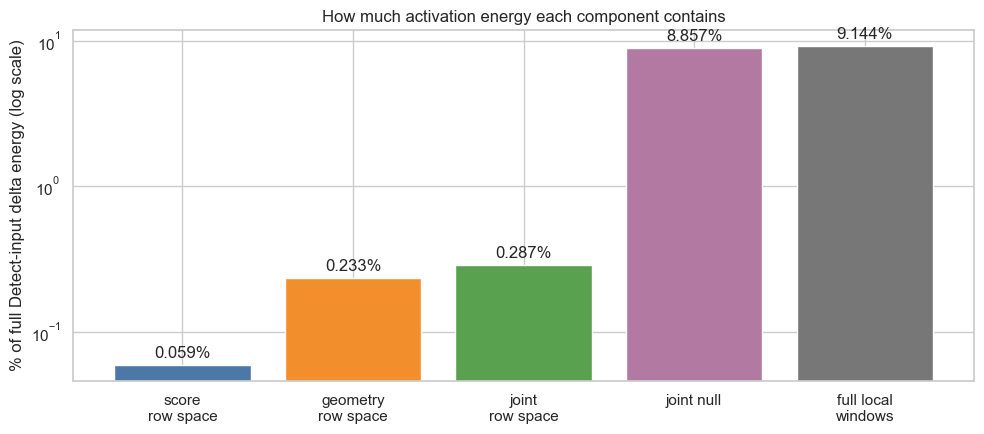

In [8]:
energy = transplant.mean_component_energy_fraction.reindex(conditions[:-1])
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels[:-1], 100 * energy.values,
              color=["#4C78A8", "#F28E2B", "#59A14F", "#B279A2", "#777777"])
ax.bar_label(bars, labels=[f"{100*v:.3f}%" for v in energy.values], padding=3)
ax.set_yscale("log")
ax.set_ylabel("% of full Detect-input delta energy (log scale)")
ax.set_title("How much activation energy each component contains")
plt.tight_layout()
plt.show()


Joint score+geometry row space занимает в среднем **0.289%** всей Detect-input delta energy.
Локальный orthogonal residual — 8.86%, полный `5×5` core — 9.15%. То есть почти вся энергия core
не является линейно видимым score/IoU signal, но примерно половина attacks нуждается в ней как
в nonlinear enabling context. Это уточняет исходную гипотезу: важна не большая энергия в
«важных нейронах», а маленькая функциональная компонента плюс состояние локального нелинейного
контекста.


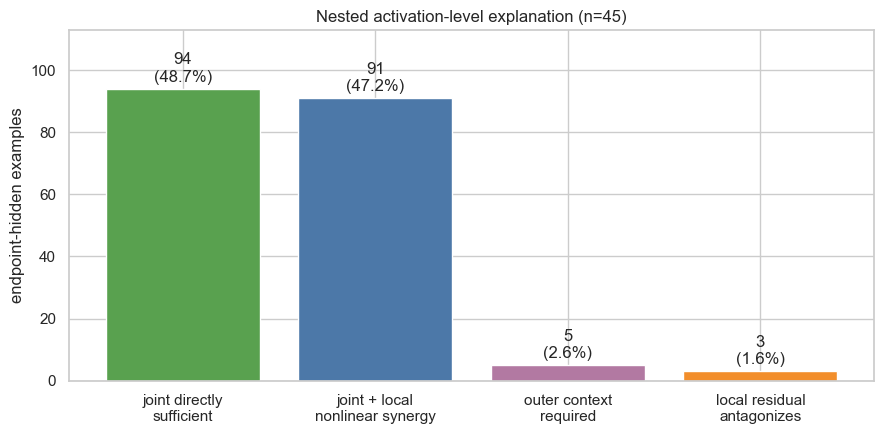

In [9]:
overall = activation_summary[activation_summary.analysis_group.eq("all")].sort_values("n", ascending=False)
label_map = {
    "direct_joint_sufficiency": "joint directly\nsufficient",
    "joint_plus_local_nonlinear_synergy": "joint + local\nnonlinear synergy",
    "joint_sufficient_but_local_residual_antagonizes": "local residual\nantagonizes",
    "outer_context_required": "outer context\nrequired",
}
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar([label_map[value] for value in overall.activation_mechanism], overall.n,
              color=["#59A14F", "#4C78A8", "#B279A2", "#F28E2B"])
ax.bar_label(bars, labels=[f"{n}\n({100*f:.1f}%)" for n, f in zip(overall.n, overall.fraction)], padding=3)
ax.set_ylabel("endpoint-hidden examples")
ax.set_title("Nested activation-level explanation (n=45)")
ax.set_ylim(0, max(overall.n) * 1.2)
plt.tight_layout()
plt.show()


На activation level получено почти симметричное разбиение: в 21/45 (46.7%) joint-functional
component достаточен напрямую; ещё 21/45 требуют его нелинейной кооперации с local residual.
Два случая (4.4%) требуют внешнего кольца до `radius=4`. В одном случае joint один скрывает target,
но добавление local residual временно антагонистично; outer context возвращает настоящий endpoint.
Все четыре категории заканчиваются полным hiding при `radius=4`, поэтому они исчерпывают
functional denominator, а не оставляют «необъяснённый хвост».


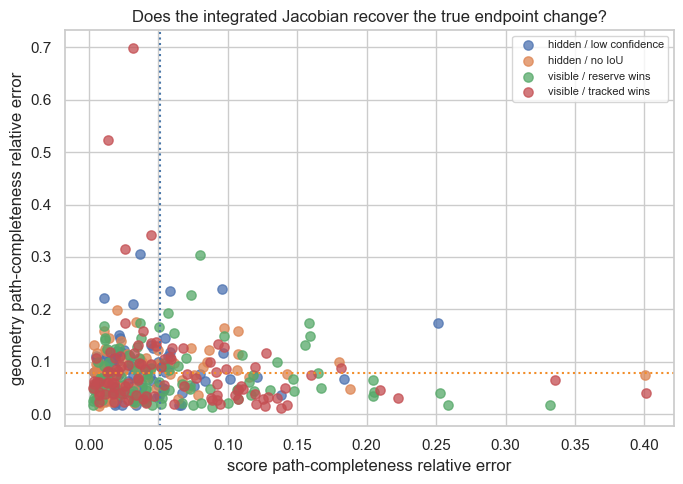

                           score_completeness_error  \
analysis_group                                        
hidden_low_conf_match                        0.0364   
hidden_no_iou_match                          0.0361   
visible_non_target_winner                    0.0665   
visible_target_winner                        0.0654   

                           geometry_completeness_error  \
analysis_group                                           
hidden_low_conf_match                           0.0820   
hidden_no_iou_match                             0.0762   
visible_non_target_winner                       0.0739   
visible_target_winner                           0.0833   

                           score_completeness_cosine  \
analysis_group                                         
hidden_low_conf_match                         0.9991   
hidden_no_iou_match                           0.9986   
visible_non_target_winner                     0.9971   
visible_target_winner                   

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for group, frame in metadata.groupby("analysis_group"):
    ax.scatter(frame.score_completeness_error, frame.geometry_completeness_error,
               alpha=0.75, s=45, label=GROUP_LABELS[group])
ax.axvline(metadata.score_completeness_error.mean(), color="#4C78A8", linestyle=":")
ax.axhline(metadata.geometry_completeness_error.mean(), color="#F28E2B", linestyle=":")
ax.set(xlabel="score path-completeness relative error",
       ylabel="geometry path-completeness relative error",
       title="Does the integrated Jacobian recover the true endpoint change?")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(metadata.groupby("analysis_group")[
    ["score_completeness_error", "geometry_completeness_error",
     "score_completeness_cosine", "geometry_completeness_cosine"]
].mean().round(4))


Пяти midpoint-шагов достаточно для верного функционального разложения: средняя relative error
равна 5.1% для person logits и 7.6% для decoded IoU; mean cosine около 0.998 и 0.997.
Ошибки не концентрируются только в hidden-группах. Поэтому превосходство joint row space нельзя
объяснить неработающей линейзацией geometry; одновременно ненулевая ошибка и transplant-асимметрия
не позволяют ошибочно назвать весь механизм линейным.


## Итоговая причинная модель

Полная успешность patch attack на фиксированный target в этом detector описывается так:

1. **Логический endpoint.** Должен исчезнуть весь candidate reserve, а не только tracked cell.
2. **Ветвление.** В 67% случаев это делает score branch; в остальных существенны geometry,
   score–geometry cooperation или NMS.
3. **Функциональное ядро.** Реальный clean→patch delta обязан иметь компонент в совместном
   score+IoU-sensitive row space candidate ensemble. Этот компонент содержит около 0.3% полной
   feature energy, но его удаление ремонтирует 100% проверенных successful attacks.
4. **Нелинейное разрешение.** Joint component напрямую достаточен лишь примерно в половине случаев.
   Большой orthogonal residual не скрывает target один, но вместе с joint component переводит
   head в нужный нелинейный режим ещё примерно в половине случаев.
5. **Пространственное замыкание.** Весь mediator помещается в `9×9` окрестность target-candidate
   routes: 5.2% Detect-input coordinates и 17% delta energy воспроизводят 193/193 hiding outcomes,
   не скрывая ни одного genuinely visible control target.

Это сильнее исходных гипотез «патч расползся / не расползся» и «попал / не попал в важные нейроны».
Корректная формулировка:

> Атака успешна, когда target-local delta содержит score+geometry-functional component,
> совместно подавляющий candidate reserve, а локальный nonlinear context и, редко, соседний
> NMS-context делают этот компонент достаточным для пересечения всех detection thresholds.

## Граница вывода

«Полное» здесь означает causal closure для этого YOLO detector, этого патча, выбранной точки
Detect input и данного target-aware outcome. Это ещё не универсальный закон для всех детекторов.
Для paper-level generalization нужны повтор на другой detector family/patch и layerwise проверка
того же nested decomposition. Functional basis пока oracle: он использует clean–patched pair.

## Как повторить тяжёлый расчёт

Из корня репозитория:

```bash
conda run -n IAD python -m CandidateRoutingAndAttackPath.run_followup_experiments full_success --device cpu
```

Прогон, показанный здесь, занял около 5.5 минут и сохранил только компактные CSV/JSON.
Повторно запускать его для просмотра ноутбука не нужно.
